# ModelFlow in the browser (JupyterLite)

Python runs inside your browser (Pyodide); nothing is installed on your computer.
The first cell installs ModelFlow into the browser session. It takes a little while the
first time and has to be run again each time the page is reloaded.

## Now import ModelFlow

In [2]:
import sys
if sys.platform == 'emscripten':  # only in the browser (JupyterLite): install ModelFlow, see mfsetup.py
    %run mfsetup.py
    await install_modelflow()

In [3]:
from modelclass import model

## Load the Pakistan model and run the baseline

In [4]:
mpak,bline = model.modelload('data/pak.pcim',run=True,keep='Baseline')

Zipped file read:  data\pak.pcim
The feedback variables are not directly connected, so the feedback order is left as found


Now we got a model `mpak` and a dataframe with a baseline `bline` 

A **dataframe** is a matix of all variable in the model with **variables** as columns and **years** as rows.

So we got all which is needed for creating experiments with the model. 

## Simulating the impact of imposing a carbon price

A simulation follows three steps:

1. **Create a scenario DataFrame** from a baseline using `.upd()`, which applies an update expression that updates selected variables over a chosen time range.
2. **Solve the model** by calling it with the scenario DataFrame, a start and end year, and a `keep=` label that names the scenario for later comparison.
3. **Inspect results** on the returned DataFrame or directly on the model, which stores each kept scenario.

### Create a scenario Dataframe

In [5]:
CT30df = bline.upd("<2025 2050> PAKGGREVCO2CER PAKGGREVCO2GER PAKGGREVCO2OER = 30")

**Breakdown** 


$$
\begin{aligned}
&\underbrace{\texttt{CT30df}}_{\text{scenario dataframe}}
 = \underbrace{\texttt{bline}}_{\text{baseline dataframe}}
 \,.\,\underbrace{\texttt{upd}}_{\text{accessor}}\bigl(\texttt{"}\ldots\texttt{"}\bigr) \\[8pt]
&\text{where the update string is} \\[4pt]
&\texttt{"}\,
 \overbrace{\texttt{<2025 2050>}}^{\text{years}}\ 
 \overbrace{\texttt{PAKGGREVCO2CER PAKGGREVCO2GER PAKGGREVCO2OER}}^{\text{coal, gas, oil CO}_2\text{ tax rates}}\ 
 \overbrace{\texttt{=}}^{\text{set}}\ 
 \overbrace{\texttt{30}}^{\text{USD/tCO}_2}
 \,\texttt{"}
\end{aligned}
$$

### Solve the model

In [6]:
resultsdf = mpak(CT30df,2020,2050,keep="Nominal $30 USD Carbon tax")

**Breakdown**
$$
\small
\underbrace{\texttt{resultsdf}}_{\text{results df}}
= \underbrace{\texttt{mpak}}_{\text{model}}\bigl(
\underbrace{\texttt{CT30df}}_{\text{scenario df}},\;
\underbrace{\texttt{2020}}_{\text{start}},\;
\underbrace{\texttt{2050}}_{\text{end}},\;
\underbrace{\texttt{keep="Nominal \$30USD Carbon tax"}}_{\text{scenario label}}
\bigr)
$$

where **df** is short for **dataframe** 

### Inspect results

 **Note**
 
 `resultsdf` is rarely used directly. The model object `mpak` keeps the baseline (`mpak.basedf`) and the latest run (`mpak.lastdf`) internally, so the following cells can compare and plot results directly from `mpak`.

 In the widget below the result for the variables `PAKNYGDPMKTPCN PAKFMLBLPOLYXN PAKCCEMISCO2?KN` can be inspected. Try selecting the different tabs. 

In [13]:
mpak['PAKNYGDPMKTPCN PAKFMLBLPOLYXN PAKCCEMISCO2?KN']

In [15]:
mpak['PAKNYGDPMKTPCN PAKFMLBLPOLYXN PAKCCEMISCO2?KN'].rplot(samefig=0,datatype='difpctlevel',tab=True)

Accordion(children=(HTML(value='<?xml version="1.0" encoding="utf-8" standalone="no"?>\n<!DOCTYPE svg PUBLIC "…

In [8]:
mpak.PAKNYGDPMKTPCN

Endogeneous: PAKNYGDPMKTPCN: GDP, Market Prices, LCU mn
Formular: FRML <IDENT> PAKNYGDPMKTPCN = PAKNECONPRVTCN+PAKNECONGOVTCN+PAKNEGDIFTOTCN+PAKNEGDISTKBCN+PAKNEEXPGNFSCN-PAKNEIMPGNFSCN+PAKNYGDPDISCCN+PAKADAP*PAKDISPREPCN $

PAKNYGDPMKTPCN: GDP, Market Prices, LCU mn
PAKADAP       : 
PAKDISPREPCN  : 
PAKNECONGOVTCN: Govt. Cons., LCU mn
PAKNECONPRVTCN: Pvt. Cons., LCU mn
PAKNEEXPGNFSCN: Exp., GNFS (NIA), millions LCU
PAKNEGDIFTOTCN: Fixed Domestic Inv., LCU mn
PAKNEGDISTKBCN: Change in stock, LCU mn
PAKNEIMPGNFSCN: Imp., GNFS (NIA), LCU mn
PAKNYGDPDISCCN: GDP Disc., LCU mn

Values :


,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
Base,"46,180,354.38","51,579,657.84","56,985,483.87","62,594,067.46","68,528,624.21","74,841,107.69","81,534,690.39","88,606,943.09","96,077,333.66","103,995,385.87","112,434,273.39","121,479,584.07","131,220,349.58","141,745,097.05","153,142,299.77","165,503,150.02","178,924,737.94","193,512,462.91","209,381,544.91","226,657,745.58","245,477,825.40","265,990,074.87","288,355,119.80","312,747,059.02","339,354,898.82","368,384,181.75","400,058,773.44","434,622,752.61","472,342,412.83","513,508,380.90","558,437,878.73"
Last,"46,180,354.38","51,579,657.84","56,985,483.88","62,594,067.47","68,528,624.22","76,456,563.86","83,849,698.53","91,343,760.59","99,049,769.43","107,102,706.90","115,610,352.20","124,693,188.96","134,461,553.78","145,015,555.89","156,450,188.79","168,861,628.41","182,351,453.59","197,028,934.40","213,012,089.21","230,428,165.92","249,414,162.32","270,117,690.15","292,698,204.20","317,328,544.17","344,196,619.86","373,507,172.22","405,483,581.42","440,369,730.48","478,431,966.01","519,961,198.85","565,275,178.27"
Diff,0.00,0.00,0.01,0.01,0.01,"1,615,456.17","2,315,008.15","2,736,817.49","2,972,435.77","3,107,321.03","3,176,078.81","3,213,604.88","3,241,204.21","3,270,458.84","3,307,889.02","3,358,478.38","3,426,715.65","3,516,471.50","3,630,544.30","3,770,420.33","3,936,336.91","4,127,615.28","4,343,084.40","4,581,485.15","4,841,721.04","5,122,990.47","5,424,807.98","5,746,977.87","6,089,553.17","6,452,817.95","6,837,299.54"


Input last run:


,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
PAKADAP,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
PAKDISPREPCN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
PAKNECONGOVTCN,"5,556,614.46","6,367,939.34","7,216,641.71","8,120,204.64","9,082,310.70","10,821,102.98","12,203,133.90","13,494,241.34","14,787,018.21","16,122,188.49","17,510,775.24","18,971,313.35","20,519,431.36","22,168,291.60","23,929,718.91","25,815,610.94","27,838,763.09","30,013,391.33","32,355,433.31","34,882,679.68","37,614,832.75","40,573,555.71","43,782,540.26","47,267,611.58","51,056,859.54","55,180,795.98","59,672,536.70","64,568,007.73","69,906,180.21","75,729,337.26","82,083,375.96"
PAKNECONPRVTCN,"39,450,086.71","43,735,888.95","47,954,011.20","52,344,927.02","57,045,147.67","63,076,447.95","68,578,723.62","74,358,087.31","80,378,603.30","86,715,179.07","93,450,257.83","100,668,700.56","108,447,209.55","116,855,311.03","125,960,539.49","135,833,808.76","146,552,702.85","158,202,774.74","170,877,728.24","184,679,237.41","199,716,980.81","216,109,123.81","233,983,206.17","253,477,331.65","274,741,481.36","297,938,884.35","323,247,425.05","350,861,103.26","380,991,587.95","413,869,901.42","449,748,258.45"
PAKNEEXPGNFSCN,"3,628,934.80","4,153,778.82","4,740,216.42","5,380,480.49","6,071,922.73","6,810,256.02","7,619,191.55","8,477,732.84","9,390,249.84","10,360,796.59","11,394,842.91","12,499,037.10","13,680,994.31","14,949,070.92","16,312,247.72","17,780,114.12","19,362,911.20","21,071,593.90","22,917,895.18","24,914,390.99","27,074,570.86","29,412,920.11","31,945,017.07","34,687,645.94","37,658,923.33","40,878,436.18","44,367,389.07","48,148,760.22","52,247,466.53","56,690,538.74","61,507,308.28"
PAKNEGDIFTOTCN,"5,357,846.53","5,945,053.34","6,516,455.63","7,079,977.54","7,649,429.94","8,756,122.54","9,535,966.19","10,288,945.09","11,064,480.34","11,887,870.37","12,773,927.70","13,742,038.40","14,811,220.99","15,999,382.93","17,323,328.68","18,799,297.95","20,443,505.55","22,272,645.95","24,304,320.66","26,557,377.41","29,052,199.11","31,810,978.24","34,857,994.48","38,219,909.50","41,926,071.54","46,008,828.12","50,503,846.35","55,450,441.69","60,891,920.68","66,875,944.64","73,454,920.23"
PAKNEGDISTKBCN,"655,457.50","711,986.84","773,391.50","840,091.95","912,544.92","991,246.53","1,076,735.69","1,169,597.79","1,270,468.69","1,380,039.12","1,499,059.34","1,628,344.36","1,768,779.44","1,921,326.22","2,087,029.27","2,267,023.22","2,462,540.58","2,674,920.17","2,905,616.24","3,156,208.48","3,428,412.82","3,724,093.19","4,045,274.23","4,394,155.25","4,773,125.19","5,184,779.06","5,631,935.64","6,117,656.83","6,645,268.61","7,218,383.78","7,840,926.76"
PAKNEIMPGNFSCN,"8,468,585.89","9,334,989.73","10,215,232.88","11,171,614.50","12,232,732.08","13,998,612.55","15,164,052.85","16,444,844.24","17,841,051.45","19,363,367.28","21,018,511.40","22,816,245.45","24,766,082.57","26,877,827.56","29,162,676.08","31,634,227.46","34,308,970.65","37,206,392.73","40,348,905.55","43,761,729.29","47,472,835.37","51,512,982.36","55,915,829.59","60,718,111.47","65,959,842.96","71,684,553.50","77,939,553.59","84,776,241.65","92,250,460.57","100,422,909.81","109,359,614.48"
PAKNYGDPDISCCN,0.26,0.28,0.30,0.33,0.36,0.39,0.42,0.46,0.50,0.54,0.59,0.64,0.69,0.75,0.82,0.89,0.96,1.05,1.14,1.23,1.34,1.46,1.58,1.72,1.87,2.03,2.20,2.39,2.60,2.82,3.07


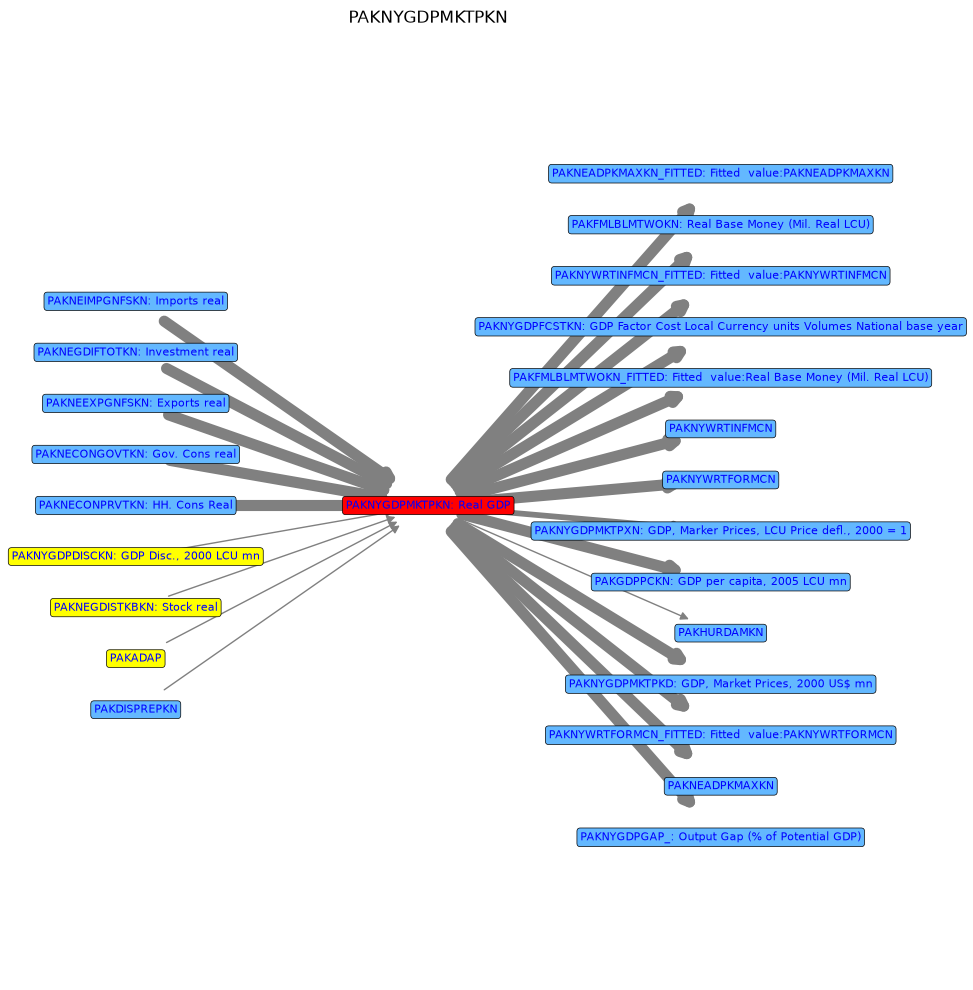

In [10]:
mpak.no_graphviz=True
mpak.draw('PAKNYGDPMKTPKN', up=1, down=1,size=(10,10),des=True)

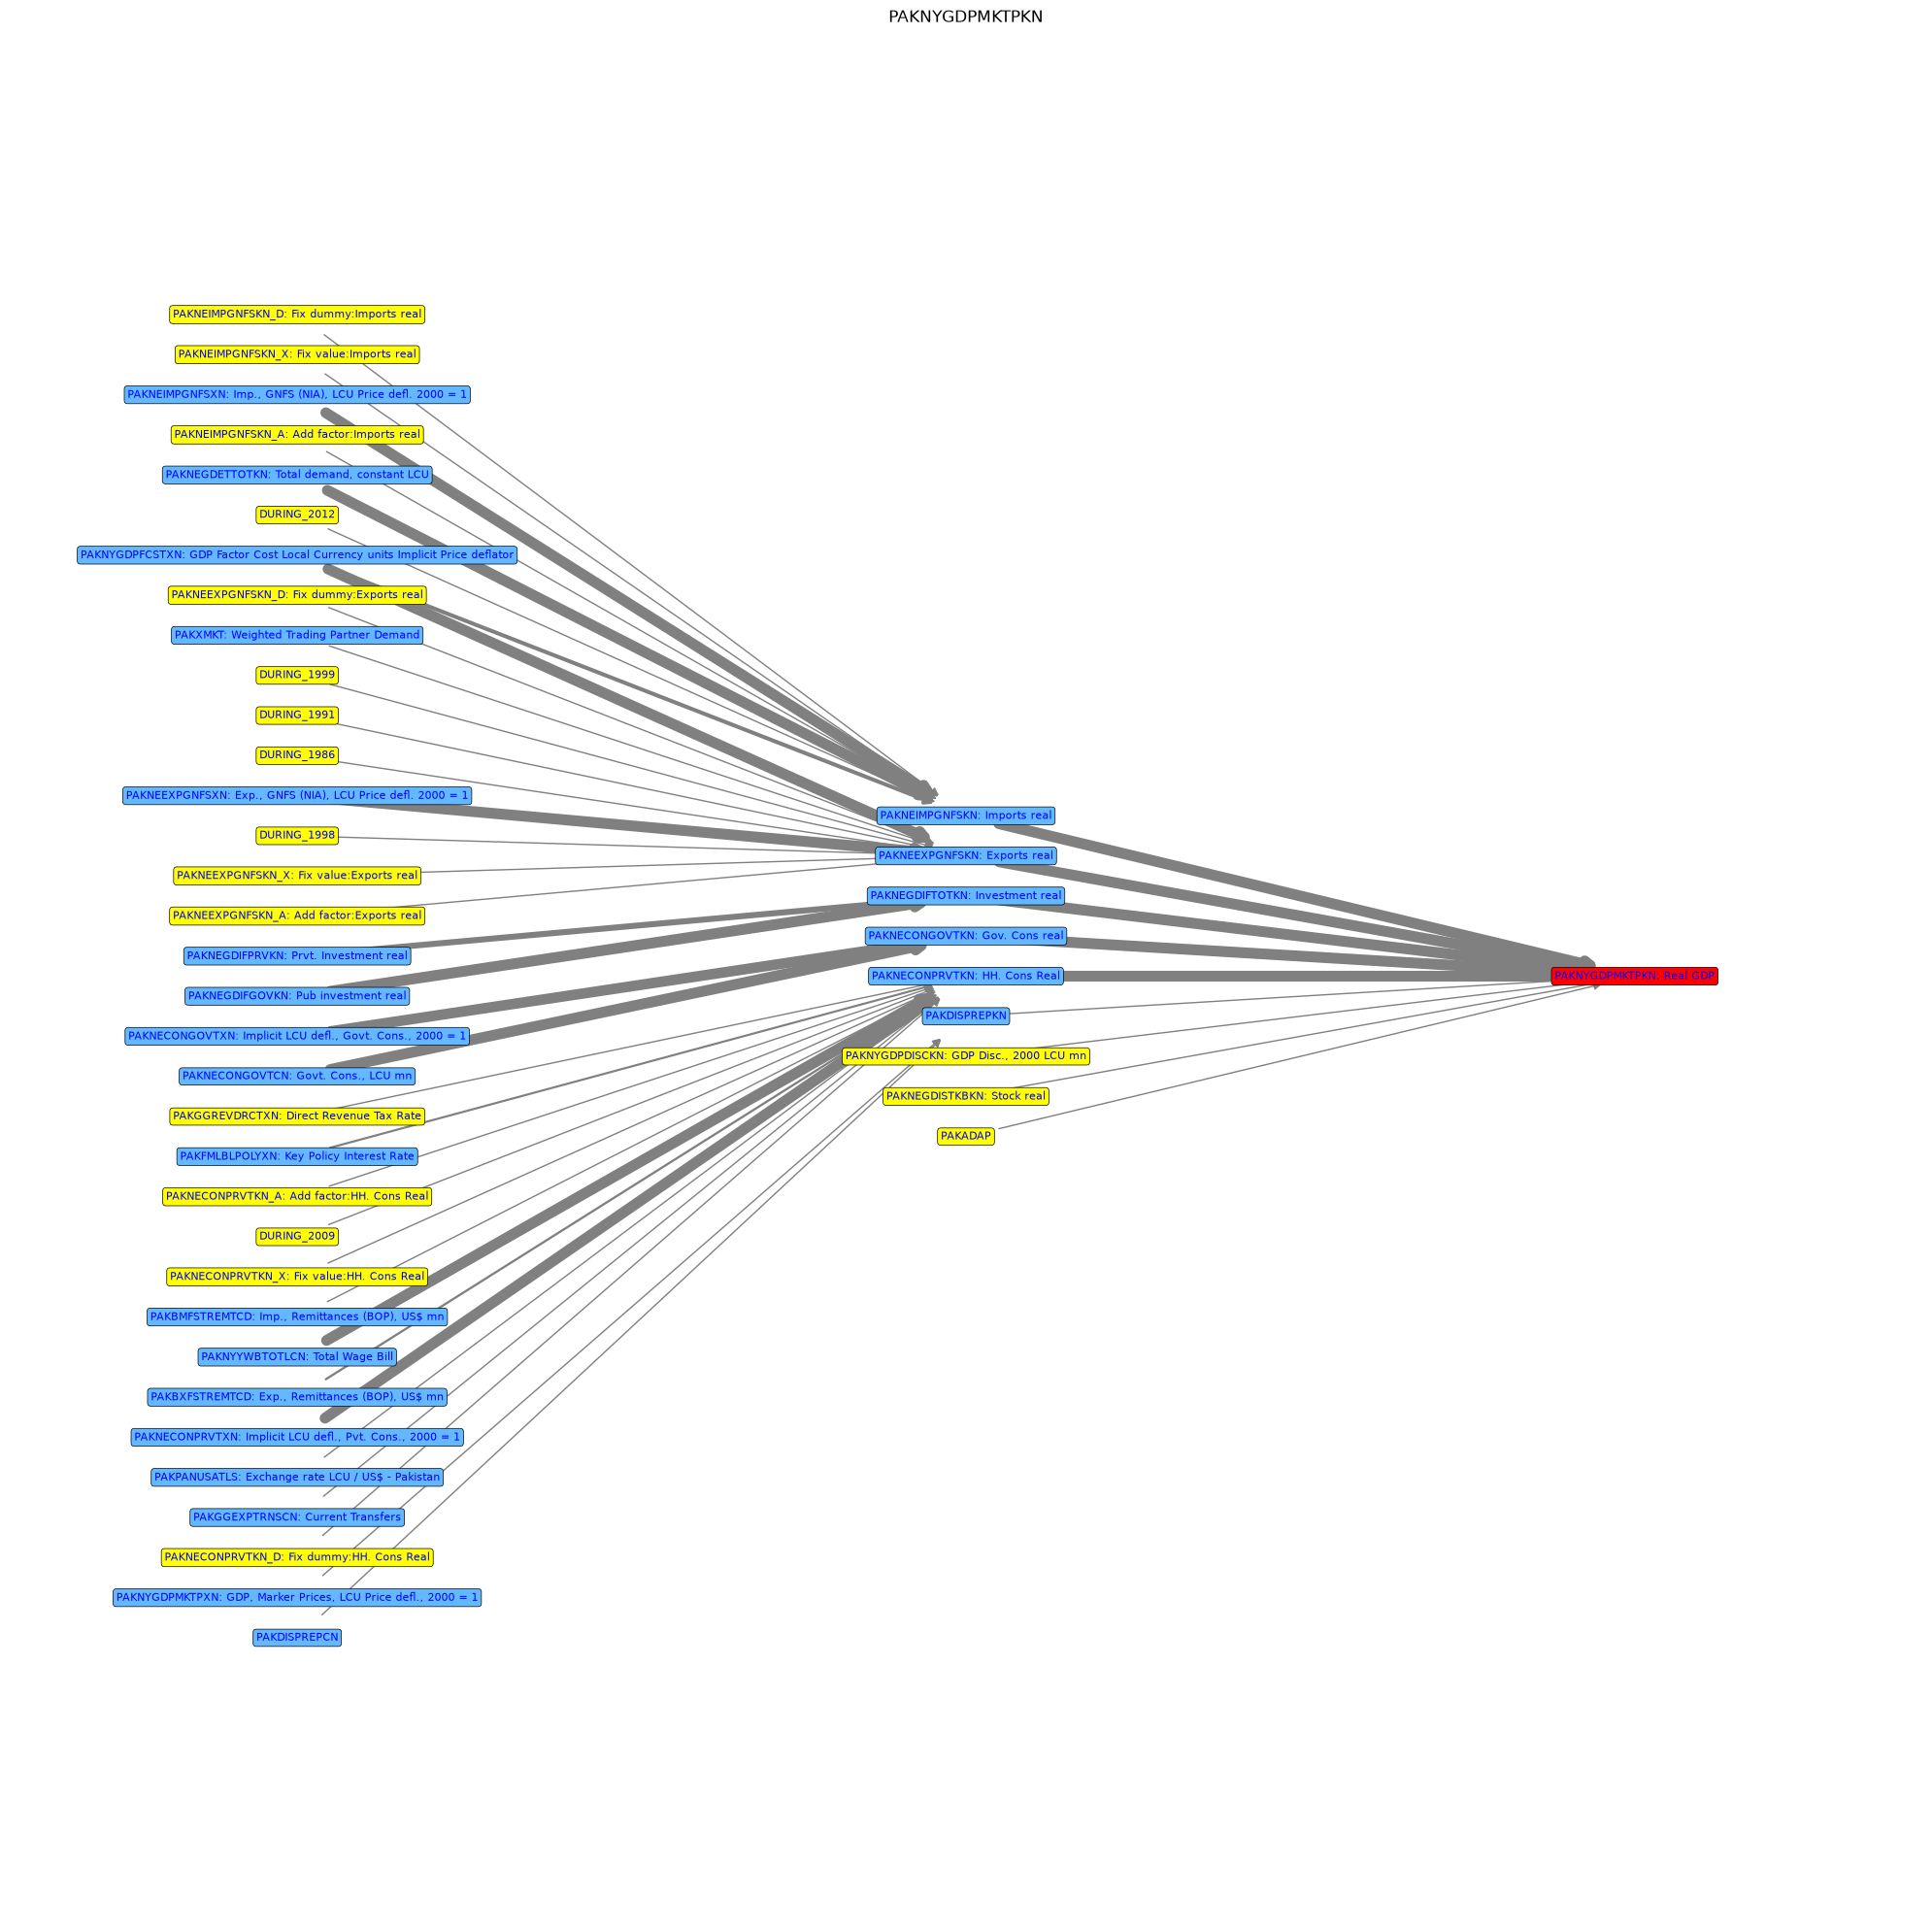

In [11]:
mpak.PAKNYGDPMKTPKN.tracepre(filter=0,up=2,size=(20,20)) 

In [12]:
mpak.draw_nx('PAKNYGDPMKTPKN', up=2, down=1, engine='svg',browser=True);